# PACKAGE

In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "img" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from scipy import stats as sps
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error, balanced_accuracy_score, precision_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier


# Y LABELS

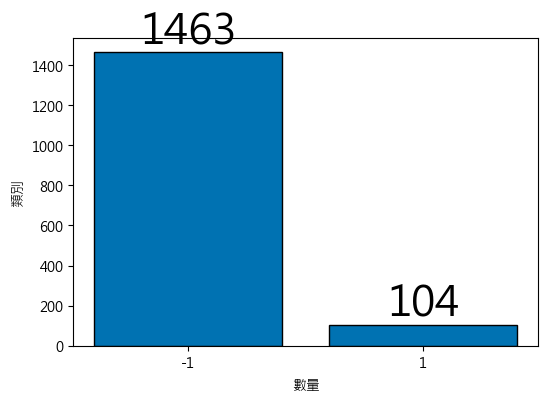

In [43]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].astype(int)

y_counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4))
bars = plt.bar(["-1", "1"], y_counts.values, color='#0072B2', edgecolor = 'k')

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, str(int(h)),
             ha='center', va='bottom', fontsize=30)
plt.xlabel("數量")
plt.ylabel("類別")
plt.show()

# X NA

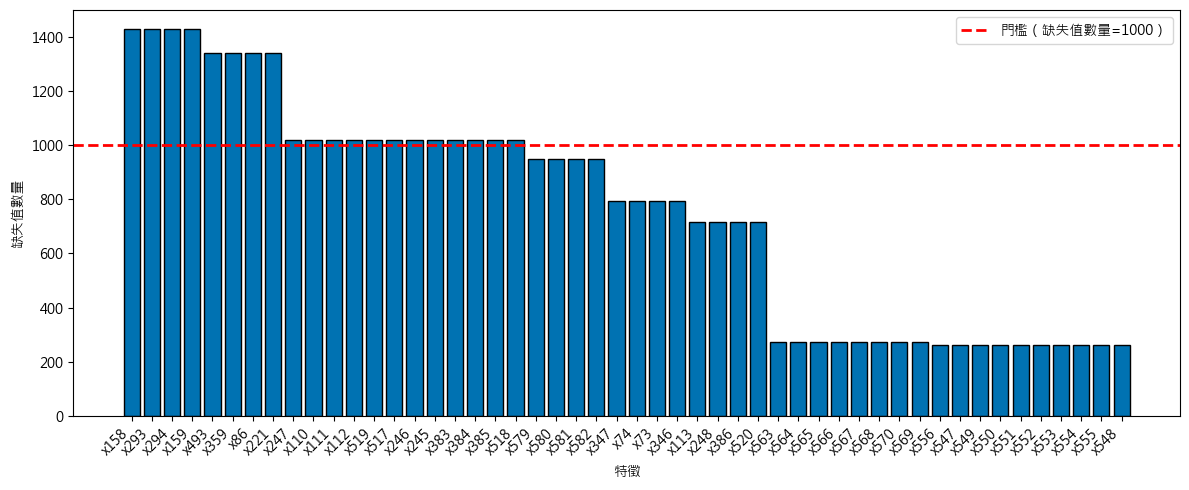

In [44]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1: 0, 1: 1}).astype(int)

na_cnt = X.isna().sum().sort_values(ascending=False)

topk = 50
na_top = na_cnt.head(topk)
x_ticks = na_top.index.tolist()

plt.figure(figsize=(12, 5))
plt.bar(range(len(na_top)), na_top.values, color='#0072B2', edgecolor = 'k')
plt.xticks(range(len(na_top)), x_ticks, rotation=45, ha='right')
plt.axhline(y=1000, color='r', linewidth=2, label='門檻（缺失值數量=1000）', linestyle='--')
plt.xlabel("特徵")
plt.ylabel("缺失值數量")
plt.legend()
plt.tight_layout()
plt.show()

# X DIFF

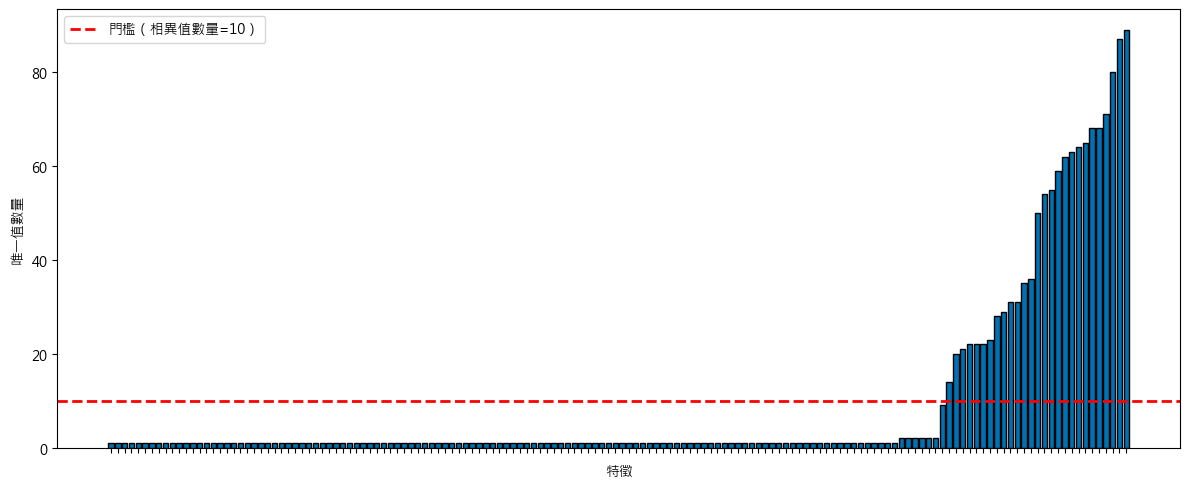

In [45]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()

uniq_counts = X.nunique(dropna=True).sort_values(ascending=True)

topk = 150
na_top = uniq_counts.head(topk)
x_ticks = na_top.index.tolist()

plt.figure(figsize=(12, 5))
plt.bar(range(len(na_top)), na_top.values, color='#0072B2', edgecolor = 'k')
plt.xticks(ticks=range(len(na_top)), labels=[''] * len(na_top))
plt.axhline(y=10, color='r', linewidth=2, label='門檻（相異值數量=10）', linestyle='--')

plt.xlabel("特徵")
plt.ylabel("唯一值數量")
plt.legend()
plt.tight_layout()
plt.show()

# X NA FEATURE NA

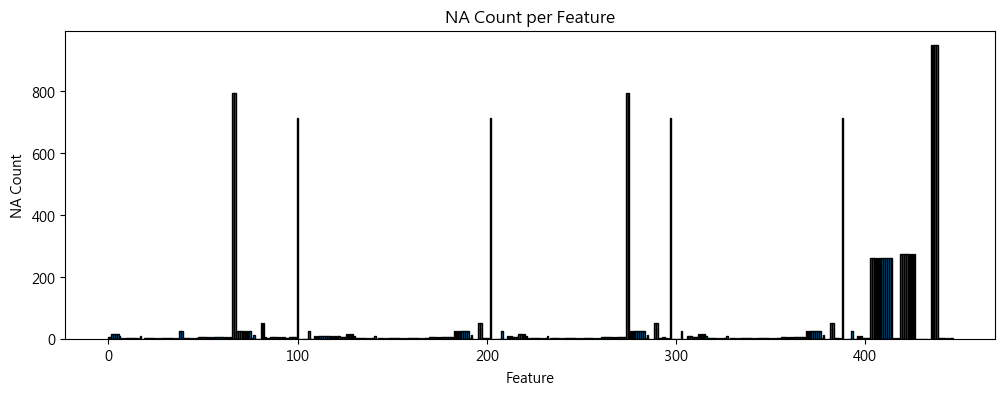

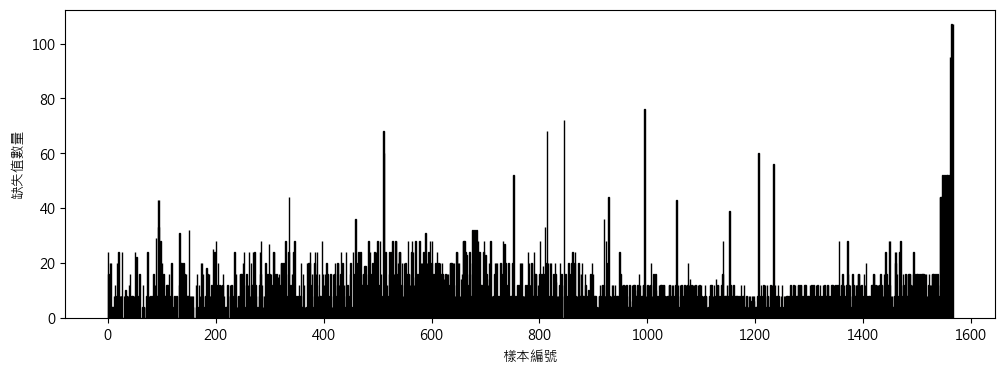

In [46]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

# 1. 每個特徵的 NA 值數量
na_counts_feature = X.isna().sum()

plt.figure(figsize=(12, 4))
plt.bar(range(len(na_counts_feature)), na_counts_feature.values, color='#0072B2', edgecolor = 'k')
plt.xlabel("Feature")
plt.ylabel("NA Count")
plt.title("NA Count per Feature")
plt.show()

# 2. 每個樣本的 NA 值數量
na_counts_sample = X.isna().sum(axis=1)

plt.figure(figsize=(12, 4))
plt.bar(range(len(na_counts_sample)), na_counts_sample.values, color='#0072B2', edgecolor = 'k')
plt.xlabel("樣本編號")
plt.ylabel("缺失值數量")
plt.show()

# PCA

PCA 保留 131 個主成分


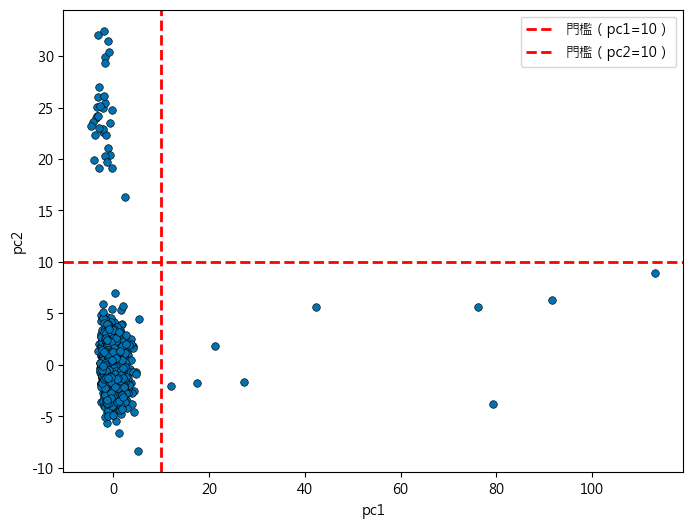

In [2]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=30, color='#0072B2', edgecolor = 'k')
# 門檻線
plt.axvline(10, linestyle='--', color='r', linewidth=2, label='門檻（pc1=10）')
plt.axhline(10, linestyle='--', color='r', linewidth=2, label='門檻（pc2=10）')
plt.legend()
plt.show()

PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


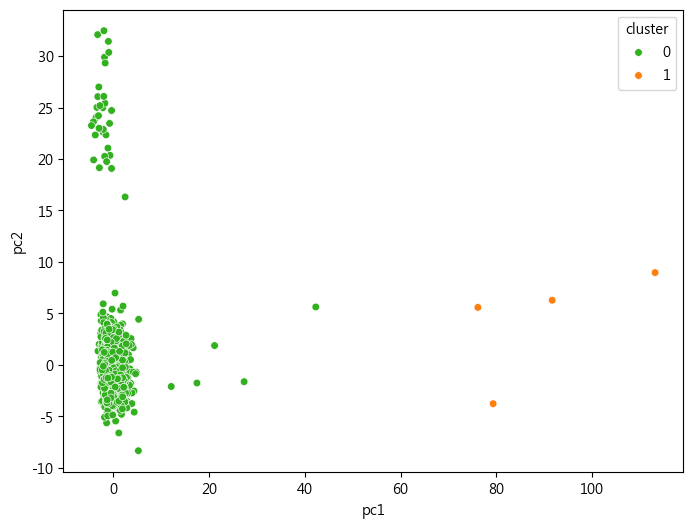

In [82]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",  # cluster 0, y=1
    1: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

PCA 保留 126 個主成分
cluster sizes: {0: 60, 1: 2134}
cluster   0     1
y                
0        25  1438
1        35   696


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


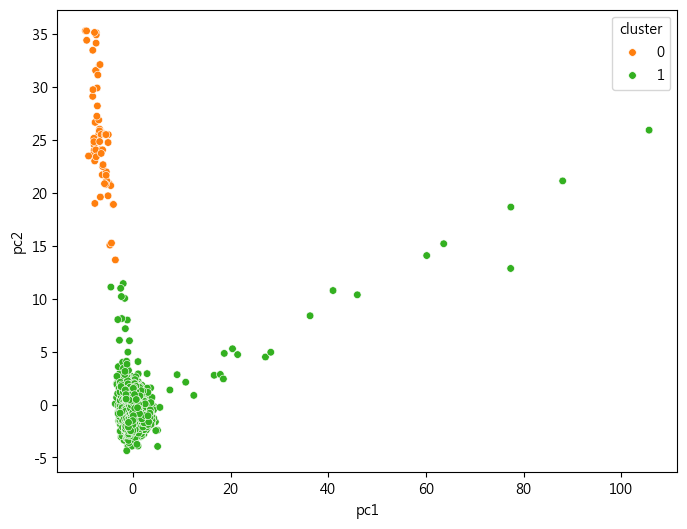

In [80]:
secom = pd.read_csv(data_path, sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    1: "#33B020",  # cluster 0, y=1
    0: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

In [10]:
X_std

,x1,x2,x3,x4,x5,x7,x8,x9,x10,x11,...,x581,x582,x583,x584,x585,x586,x587,x588,x589,x590
0,0.216411,0.856549,-0.434551,0.023500,-0.051987,-0.546749,0.256173,0.521406,1.121315,-0.372980,...,-0.349291,-0.220985,0.120331,-0.202448,-0.091826,-0.194761,-0.278654,-0.140893,-0.050083,0.201450
1,1.094037,-0.374751,1.020782,0.142049,-0.061313,0.209791,0.307169,0.468613,0.014491,-1.603007,...,0.288903,2.006795,0.532455,0.401942,0.439739,0.380511,-0.960619,0.421933,0.258167,1.167895
2,-1.114171,0.805982,-0.479627,0.670902,-0.049351,-0.886712,0.245974,-0.248829,0.319365,0.134136,...,4.526034,-0.164680,-1.263228,0.022039,0.014487,0.029495,2.972233,3.631596,3.316370,-0.171694
3,-0.354825,-0.190915,-0.049316,-1.107818,-0.052686,0.512631,0.001194,0.354905,-0.774204,-0.362190,...,-0.481485,-0.320891,-0.321230,-0.288790,-0.357609,-0.280042,-0.106352,-0.167828,-0.297870,-0.268061
4,0.234139,0.095176,1.121165,-0.167425,-0.048944,-0.101558,0.184779,0.556601,-0.157829,-0.782989,...,0.094126,0.424783,-5.914343,26.551870,26.752218,26.594405,-0.106352,-0.167828,-0.297870,-0.268061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1520,-1.563472,-0.384465,-0.707284,3.801642,-0.049806,-3.004559,0.317368,-1.618736,-0.250616,-0.621144,...,-0.337037,1.919611,-0.380105,-0.058546,0.014487,-0.055510,-1.186275,-0.292585,-0.193613,1.114111
1521,0.505750,0.340290,-0.065223,-0.622946,-0.060489,-0.409900,-0.121197,-0.388256,-0.356659,-1.009573,...,0.428640,0.356134,-0.762792,-0.127619,-0.065248,-0.122690,-1.186275,-0.292585,-0.193613,1.114111
1522,-0.488938,-1.437908,0.198417,-0.654906,-0.061415,-0.259024,-0.090599,0.295257,-0.215528,-0.411018,...,-1.396320,-0.846159,-0.409543,-0.000985,0.067643,-0.002423,-0.146648,-0.882347,-0.958164,-0.592100
1523,-1.624236,0.458114,-0.799332,-0.489650,-0.048255,-0.357294,-0.039603,0.002953,-0.429564,0.339141,...,1.011141,0.019543,0.090894,0.142917,-0.012091,0.137740,0.377195,0.920962,0.779451,-0.058046


PCA 保留 137 個主成分


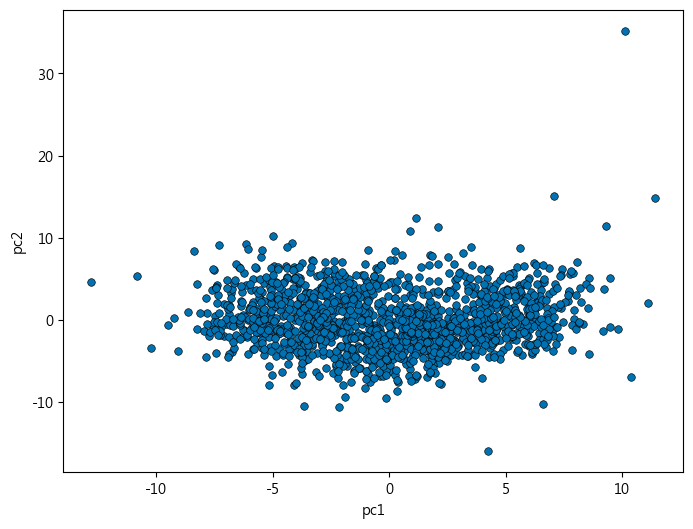

In [48]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=30, color='#0072B2', edgecolor = 'k')
plt.show()

PCA 保留 137 個主成分


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmea

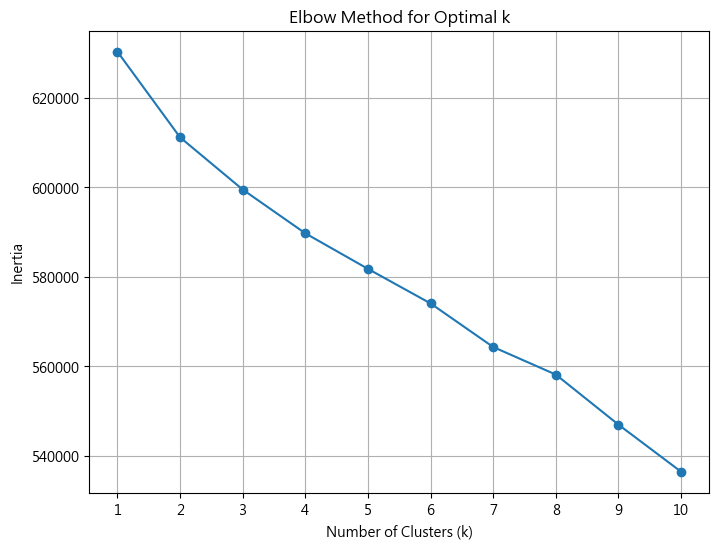

k vs inertia: [(1, 630238.6619936827), (2, 611102.317117817), (3, 599445.6952856146), (4, 589664.7573106384), (5, 581724.6025075724), (6, 574000.6619325808), (7, 564263.944999931), (8, 558105.313260109), (9, 546918.5929090027), (10, 536404.8916913887)]
d1 (improvement): [19136.34487587 11656.6218322   9780.93797498  7940.15480307
  7723.94057499  9736.71693265  6158.63173982 11186.72035111
 10513.70121761]
d2 (curvature proxy): [-7479.72304366 -1875.68385723 -1840.78317191  -216.21422807
  2012.77635766 -3578.08519283  5028.08861128  -673.01913349]
Elbow-based best k = 8
cluster sizes: {0: 552, 1: 243, 2: 555, 3: 175}
cluster    0    1    2    3
y                          
0        513  231  523  163
1         39   12   32   12


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


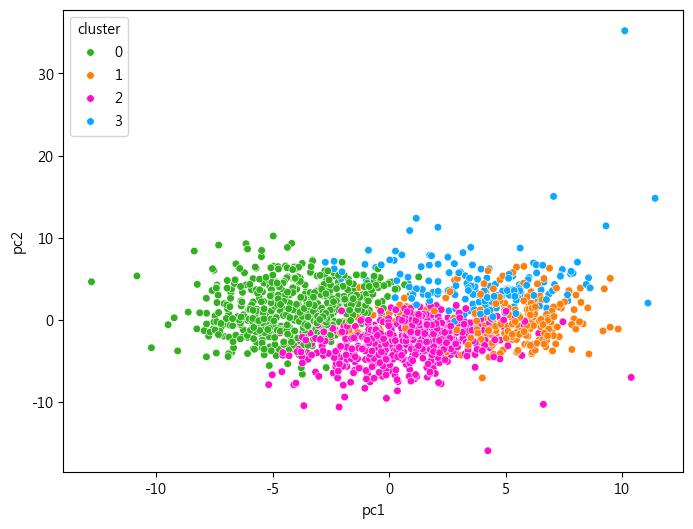

In [93]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

# 手肘法
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km.fit(X_pca_df)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True)
plt.show()

inertias_arr = np.array(inertias)

# 一階差分(下降量)，二階差分(下降量的變化)
d1 = -np.diff(inertias_arr)         # 越大代表多加一群帶來的改善越大
d2 = np.diff(d1)                    # 越大代表改善幅度「突然變小」(手肘)

# 手肘點：二階差分最大的位置 (對應到 k = index + 2)
k_best = int(np.argmax(d2) + 2)

print("k vs inertia:", list(zip(list(K_range), inertias)))
print("d1 (improvement):", d1)
print("d2 (curvature proxy):", d2)
print(f"Elbow-based best k = {k_best}")

kmeans = KMeans(n_clusters=4, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",
    1: '#ff7f0e',
    2: "#ff0ecb",
    3: "#0ea7ff"
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()



PCA 保留 137 個主成分
cluster sizes: {0: 718, 1: 807}
cluster    0    1
y                
0        660  770
1         58   37


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


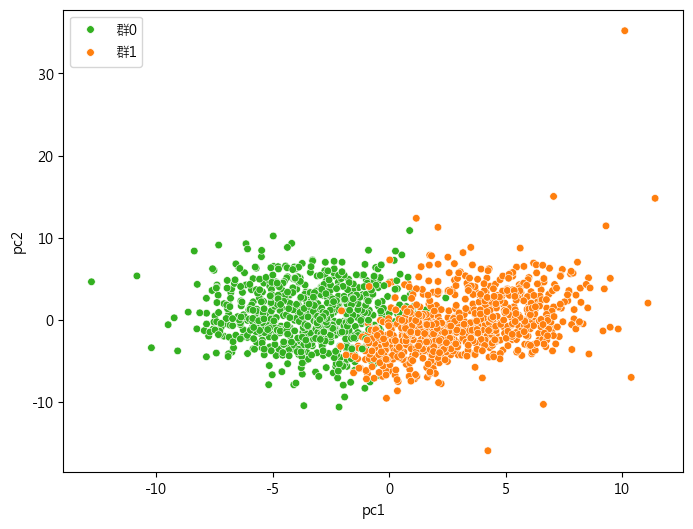

In [8]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels
X_pca_df['cluster'] = X_pca_df['cluster'].replace({1:'群1', 0:'群0'})

plt.figure(figsize=(8,6))
palette = {
    '群0': "#33B020",  # cluster 0
    '群1': '#ff7f0e',  # cluster 1
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.legend(loc='best')
plt.show()

PCA 保留 125 個主成分


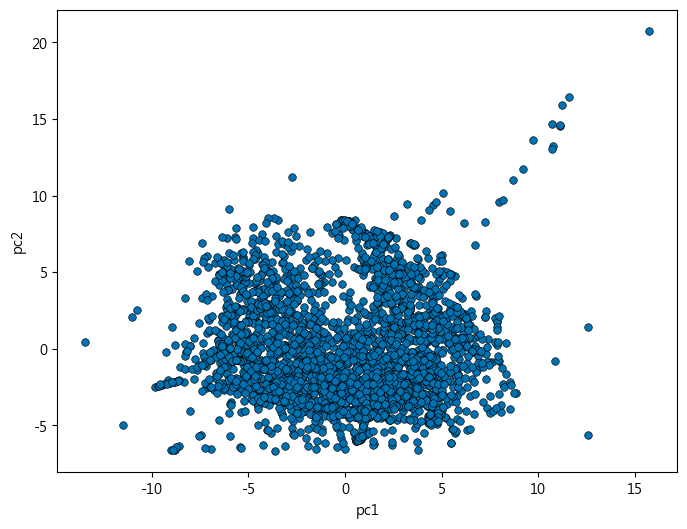

In [50]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=30, color='#0072B2', edgecolor = 'k')
plt.show()

PCA 保留 125 個主成分


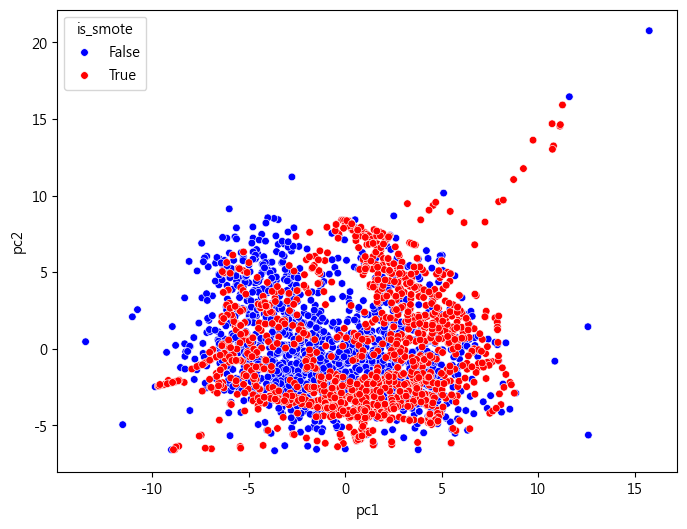

In [16]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
# 1) 在 SMOTE 後保留 index（最低限度修改：只加這兩行）
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns, index=X_smote.index)

# 2) PCA 後把「是否為合成樣本」帶到投影空間
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)], index=X_smote_df.index)

# 3) 合成樣本判定：SMOTE 新增的那些 index 不在原始 X_std.index
X_pca_df['is_smote'] = ~X_pca_df.index.isin(X_std.index)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=X_pca_df, x='pc1', y='pc2',
    hue='is_smote', palette={False:'b', True:'r'},
    s=30, legend=True
)
plt.show()


PCA 保留 125 個主成分
cluster sizes: {0: 1548, 1: 1312}
cluster    0    1
y                
0        619  811
1        929  501


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


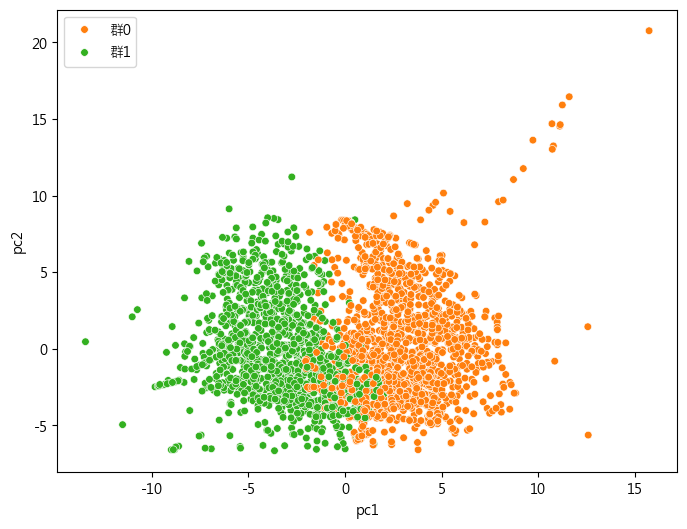

In [125]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels
X_pca_df['cluster'] = X_pca_df['cluster'].replace({1:'群1', 0:'群0'})

plt.figure(figsize=(8,6))
palette = {
    '群1': "#33B020",  # cluster 1
    '群0': '#ff7f0e',  # cluster 0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.legend(loc='best')
plt.show()

PCA 保留 125 個主成分
cluster sizes: {0: 1548, 1: 1312}
cluster    0    1
y                
0        619  811
1        929  501


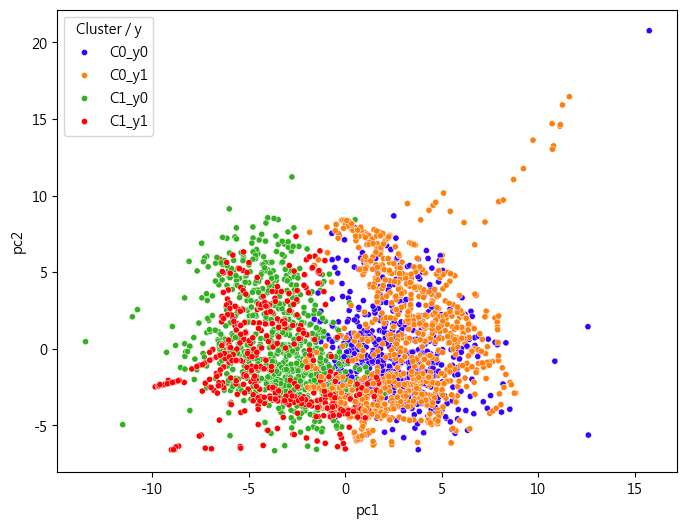

In [ ]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

X_pca_df['y'] = y_smote.values

# 建一個 4 類別欄位： (cluster, y)
X_pca_df['group'] = (
    'C' + X_pca_df['cluster'].astype(str) + '_y' + X_pca_df['y'].astype(str)
)
# 這樣會有：C0_y0, C0_y1, C1_y0, C1_y1 四種

plt.figure(figsize=(8,6))
# 自訂 4 種顏色（可自行調整）
palette = {
    'C0_y0': "#3700ff",  # cluster 0, y=0
    'C0_y1': '#ff7f0e',  # cluster 0, y=1
    'C1_y0': "#33B020",  # cluster 1, y=0
    'C1_y1': "#ff0000",  # cluster 1, y=1
}
sns.scatterplot(
    data=X_pca_df,
    x='pc1', y='pc2',
    hue='group',
    palette=palette,
    s=20
)
plt.legend(title='Cluster / y', loc='best')
plt.show()

PCA 保留 125 個主成分
PCA 保留 125 個主成分（以原始資料繪圖）
cluster sizes (original only): {0: 676, 1: 849}
cluster    0    1
y                
0        619  811
1         57   38


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


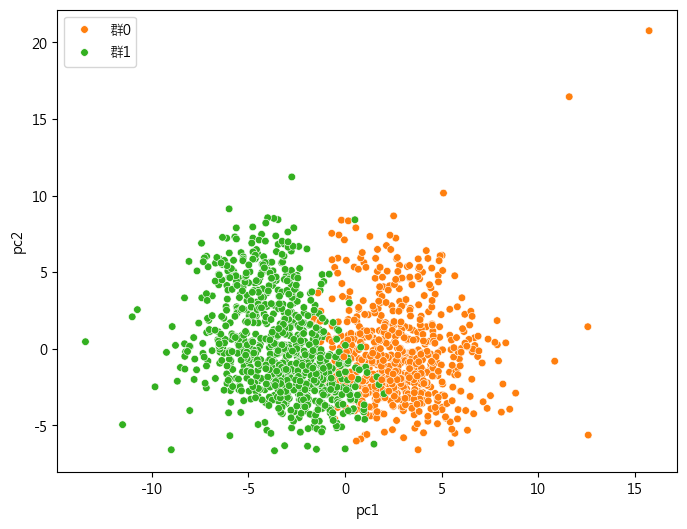

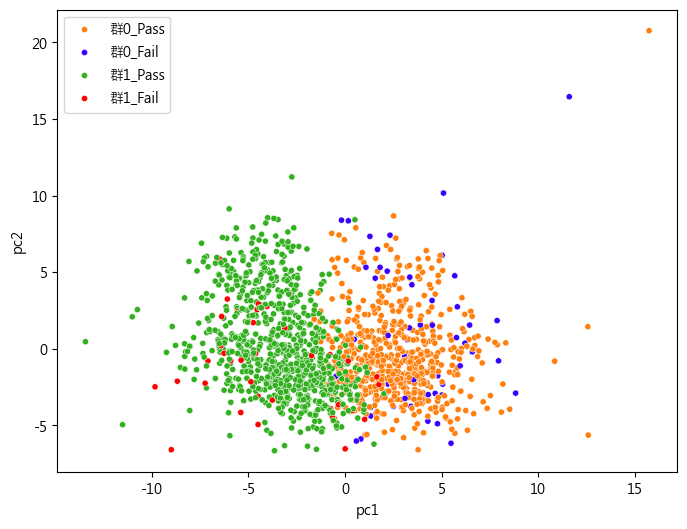

In [121]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
# 只取「原始資料」的 PCA 座標（用 X_std，不用 X_smote_df）
X_pca_org = pca.transform(X_std)
print(f'PCA 保留 {X_pca_org.shape[1]} 個主成分（以原始資料繪圖）')
X_pca_org_df = pd.DataFrame(
    X_pca_org,
    columns=[f'pc{i}' for i in range(1, X_pca_org.shape[1] + 1)],
    index=X_std.index
)

# --- KMeans：用 SMOTE 的 PCA 空間 fit（保持你原本分群依據），再對原始資料 predict ---
X_pca_smote = pca.transform(X_smote_df)
kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
kmeans.fit(X_pca_smote)

labels_org = kmeans.predict(X_pca_org)  # 原始樣本的 cluster
sizes = pd.Series(labels_org).value_counts().sort_index()
print('cluster sizes (original only):', sizes.to_dict())

# --- 列聯表：只用原始樣本（y 與 labels_org 長度一致） ---
df_org = pd.DataFrame({'y': y.values, 'label': labels_org})
ct = pd.crosstab(df_org['y'], df_org['label'], rownames=['y'], colnames=['cluster'])
print(ct)

# --- 繪圖資料：只含原始樣本 ---
X_pca_org_df['cluster'] = labels_org
X_pca_org_df['cluster'] = X_pca_org_df['cluster'].replace({0:'群0', 1:'群1'})
X_pca_org_df['y'] = y.values
X_pca_org_df['y'] = X_pca_org_df['y'].replace({0:'Pass', 1:'Fail'})
X_pca_org_df['group'] = (X_pca_org_df['cluster'].astype(str) + '_' + X_pca_org_df['y'].astype(str))

plt.figure(figsize=(8,6))
palette = {
    '群1': "#33B020",  # cluster 1, y=1
    '群0': '#ff7f0e',  # cluster 0, y=0
}
sns.scatterplot(data=X_pca_org_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.legend(loc='best')
plt.show()

plt.figure(figsize=(8, 6))
palette = {
    '群0_Pass': '#ff7f0e',  # cluster 0, y=0
    '群0_Fail': "#3700ff",  # cluster 0, y=1
    '群1_Pass': "#33B020",  # cluster 1, y=0
    '群1_Fail': "#ff0000",  # cluster 1, y=1
}
sns.scatterplot(data=X_pca_org_df, x='pc1', y='pc2', hue='group', s=20, palette=palette)
plt.legend(loc='best')
plt.show()

In [3]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群

y_real = np.asarray(y) # 真實 y

PCA 保留 131 個主成分
PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系統找不到指定的檔案。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1538

   global_idx  cluster  y_true  p_hat_oof
0           0        0       0   0.005049
1           1        0       0   0.080591
2           2        0       1   0.765585
3           3        0       0   0.193338
4           4        0       0   0.011200
count    1525.000000
mean        0.084209
std         0.137723
min         0.000472
25%         0.010189
50%         0.028001
75%         0.093357
max         0.975609
Name: p_hat_oof, dtype: float64

高機率樣本（由大到小）:
      global_idx  cluster  y_true  p_hat_oof
348          348        0       0   0.975609
212          212        0       1   0.848101
1326        1326        1       1   0.846026
1056        1056        1       0   0.843086
374          374        0       1   0.780227
289          289        0       1   0.773626
34            34        0       0   0.772280
2              2        0       1   0.765585
178          178        0       0   0.748668
181          181        0       0   0.747824
176          176        0       0   0.7

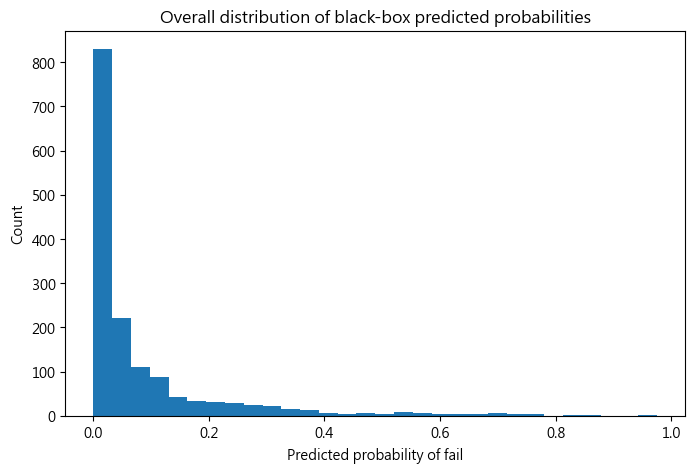

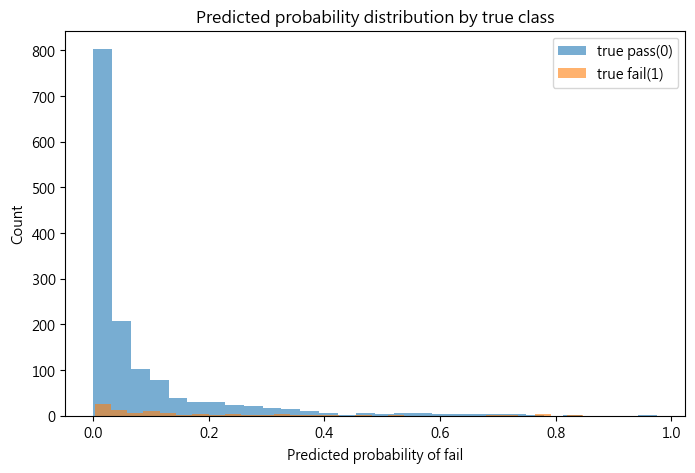

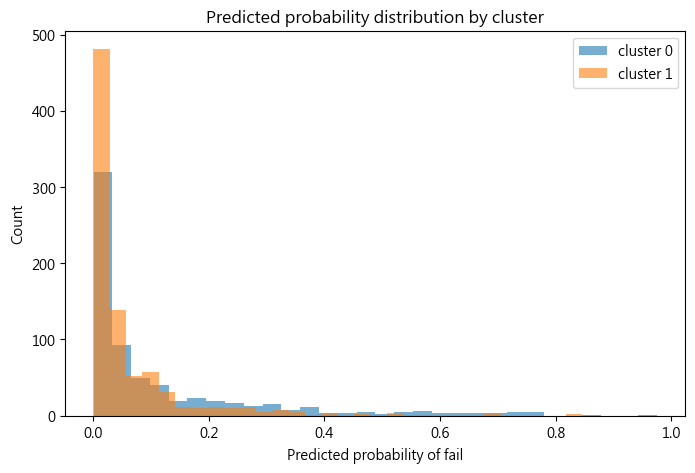

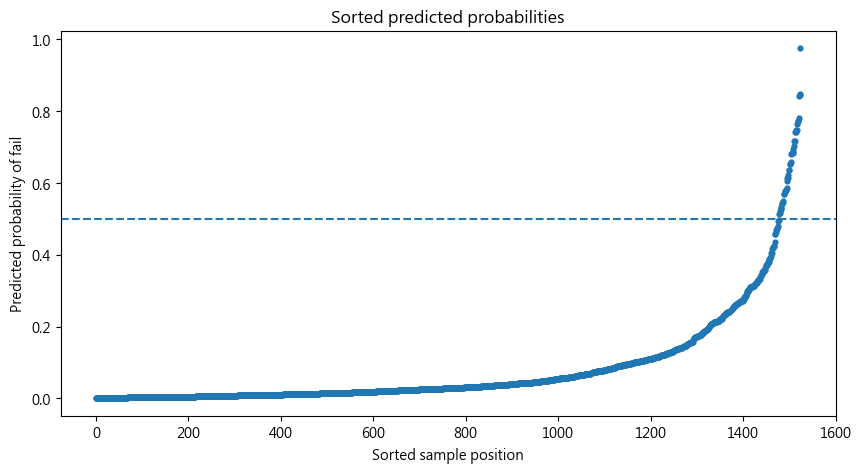

In [ ]:
def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    """
    以分群為單位做 StratifiedKFold OOF，回傳每筆真實點的 OOF 機率 p_oof。
    每個 fold 的 training 內部再做 SMOTE，避免合成點寫回 OOF。
    """
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

df_proba = pd.DataFrame({
    "global_idx": np.arange(n_real),
    "cluster": c_all,
    "y_true": y_real,
    "p_hat_oof": p_hat_oof
})

print(df_proba.head())
print(df_proba["p_hat_oof"].describe())

# 3) 看 fail 類別是否只有少數點非常確定
print("\n高機率樣本（由大到小）:")
print(df_proba.sort_values("p_hat_oof", ascending=False).head(20))

# 4) 整體機率分布圖
plt.figure(figsize=(8,5))
plt.hist(df_proba["p_hat_oof"], bins=30)
plt.xlabel("Predicted probability of fail")
plt.ylabel("Count")
plt.title("Overall distribution of black-box predicted probabilities")
plt.show()

# 5) 依真實類別分開看分布
plt.figure(figsize=(8,5))
plt.hist(df_proba.loc[df_proba["y_true"] == 0, "p_hat_oof"], bins=30, alpha=0.6, label="true pass(0)")
plt.hist(df_proba.loc[df_proba["y_true"] == 1, "p_hat_oof"], bins=30, alpha=0.6, label="true fail(1)")
plt.xlabel("Predicted probability of fail")
plt.ylabel("Count")
plt.title("Predicted probability distribution by true class")
plt.legend()
plt.show()

# 6) 依 cluster 分開看分布
plt.figure(figsize=(8,5))
plt.hist(df_proba.loc[df_proba["cluster"] == 0, "p_hat_oof"], bins=30, alpha=0.6, label="cluster 0")
plt.hist(df_proba.loc[df_proba["cluster"] == 1, "p_hat_oof"], bins=30, alpha=0.6, label="cluster 1")
plt.xlabel("Predicted probability of fail")
plt.ylabel("Count")
plt.title("Predicted probability distribution by cluster")
plt.legend()
plt.show()

# 7) 位置分布圖：把機率排序後看位置
df_plot = df_proba.sort_values("p_hat_oof").reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.scatter(np.arange(len(df_plot)), df_plot["p_hat_oof"], s=12)
plt.axhline(0.5, linestyle="--")
plt.xlabel("Sorted sample position")
plt.ylabel("Predicted probability of fail")
plt.title("Sorted predicted probabilities")
plt.show()

In [4]:
def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0, 0], cm[0, 1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_score) if np.unique(y_true).size == 2 else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

def predict_score(clf, X):
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:, 1]
    if hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        return 1 / (1 + np.exp(-s))
    return clf.predict(X).astype(float)

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 新增：bootstrap CI（用 OOF 預測做抽樣）======
def bootstrap_ci_from_oof(y_true, y_score, thr=0.5, B=10000, alpha=0.05, seed=42):
    """
    y_true: (n,) 0/1
    y_score: (n,) OOF predicted proba for positive class (Fail)
    回傳：point estimate + percentile 95% CI for ACC, FAR, ROCAU
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    n = len(y_true)
    rng = np.random.default_rng(seed)

    def met_on_arrays(yt, ys):
        yp = (ys >= thr).astype(int)
        m = compute_metrics(yt, yp, ys)
        return m['acc'], m['FAR'], m['ROCAU']

    # point
    p_acc, p_far, p_auc = met_on_arrays(y_true, y_score)

    # bootstrap
    boots = np.empty((B, 3), dtype=float)
    for b in range(B):
        idx = rng.integers(0, n, size=n)  # sample with replacement
        boots[b, :] = met_on_arrays(y_true[idx], y_score[idx])

    lo = np.nanquantile(boots, alpha / 2, axis=0)
    hi = np.nanquantile(boots, 1 - alpha / 2, axis=0)

    return {
        "ACC": (p_acc, lo[0], hi[0]),
        "FAR": (p_far, lo[1], hi[1]),
        "ROCAU": (p_auc, lo[2], hi[2]),
        "boots": boots
    }



=== XGBoost ===
Fold 1: acc=0.925, FAR=0.017, ROCAU=0.615
Fold 2: acc=0.921, FAR=0.028, ROCAU=0.695
Fold 3: acc=0.931, FAR=0.010, ROCAU=0.614
Fold 4: acc=0.921, FAR=0.021, ROCAU=0.708
Fold 5: acc=0.938, FAR=0.017, ROCAU=0.685

Confusion matrix (mean over 5 folds):
[[280.6   5.4]
 [ 16.8   2.2]]

OOF Bootstrap 95% CI (percentile):
ACC  = 0.9272 [0.9141, 0.9397]
FAR  = 0.0189 [0.0120, 0.0264]
ROCAU= 0.6623 [0.6054, 0.7178]


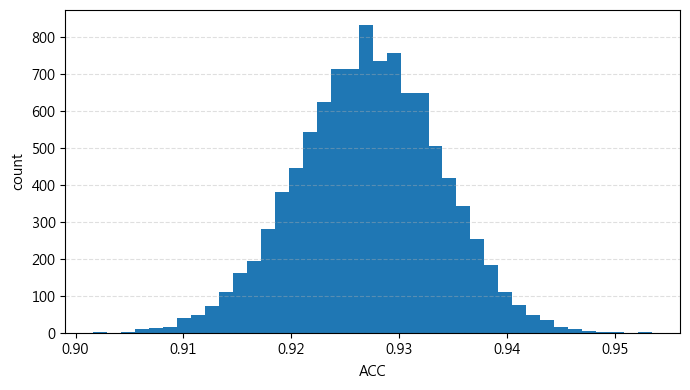

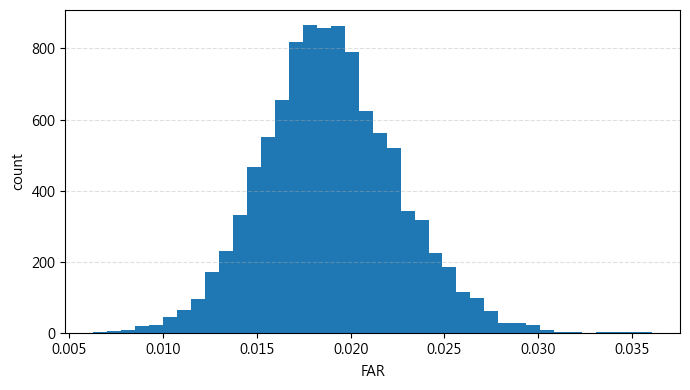

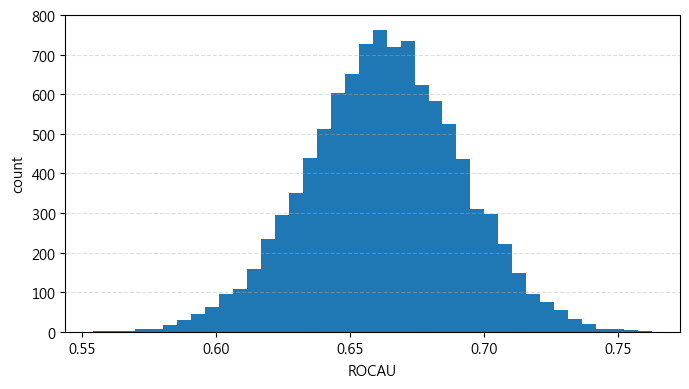


Summary (5-Fold mean):
             acc     FAR   ROCAU
model                          
XGBoost  0.9272  0.0189  0.6636


In [55]:
model = {'XGBoost':XGBClassifier(
                    n_estimators=300,
                    max_depth=3,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    min_child_weight=10,
                    gamma=1.0,
                    reg_lambda=2.0,
                    reg_alpha=0.5,
                    random_state=42,
                    n_jobs=-1,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method="hist",)}

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)

    # ====== 新增：OOF 儲存（每筆樣本只會被填一次）======
    oof_score = np.full(len(y_real), np.nan, dtype=float)  # OOF proba for positive class
    oof_true  = np.full(len(y_real), np.nan, dtype=float)  # store y_true for safety
    # ================================================

    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_all_df, y_real), 1):
        Xtr, Xte = X_all_df.iloc[train_idx], X_all_df.iloc[test_idx]
        ytr, yte = y_real[train_idx], y_real[test_idx]

        # 只對訓練集做 SMOTE
        smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)
        yhat = predict_labels(m, Xte)
        ys   = predict_score(m, Xte)
        
        # ====== 新增：寫入 OOF ======
        oof_score[test_idx] = ys
        oof_true[test_idx] = yte
        # ==========================

        met  = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    # 額外輸出：5 折平均 confusion matrix
    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)
    
    # ====== 新增：OOF bootstrap 95% CI ======
    # 注意：OOF 應該全部被填滿；若有 nan 代表流程有 bug
    valid = ~np.isnan(oof_score)
    ci = bootstrap_ci_from_oof(oof_true[valid], oof_score[valid], thr=0.5, B=10000, alpha=0.05, seed=42)
    print("\nOOF Bootstrap 95% CI (percentile):")
    print(f"ACC  = {ci['ACC'][0]:.4f} [{ci['ACC'][1]:.4f}, {ci['ACC'][2]:.4f}]")
    print(f"FAR  = {ci['FAR'][0]:.4f} [{ci['FAR'][1]:.4f}, {ci['FAR'][2]:.4f}]")
    print(f"ROCAU= {ci['ROCAU'][0]:.4f} [{ci['ROCAU'][1]:.4f}, {ci['ROCAU'][2]:.4f}]")
    
    # （可選）畫 bootstrap 分佈：三個指標各一張
    boots = ci["boots"]
    for j, lab in enumerate(["ACC", "FAR", "ROCAU"]):
        plt.figure(figsize=(7,4))
        plt.hist(boots[:, j][~np.isnan(boots[:, j])], bins=40)
        plt.xlabel(lab); plt.ylabel("count")
        plt.grid(True, axis="y", linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()
    # =====================================

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== XGBoost ===
Fold 1: acc=0.846, FAR=0.081, ROCAU=0.689
Fold 2: acc=0.904, FAR=0.040, ROCAU=0.764
Fold 3: acc=0.881, FAR=0.056, ROCAU=0.595
Fold 4: acc=0.896, FAR=0.032, ROCAU=0.696
Fold 5: acc=0.896, FAR=0.024, ROCAU=0.743

Confusion matrix (mean over 5 folds):
[[118.    5.8]
 [  9.8   1.6]]

OOF Bootstrap 95% CI (percentile):
ACC  = 0.8846 [0.8595, 0.9083]
FAR  = 0.0468 [0.0308, 0.0639]
ROCAU= 0.6983 [0.6308, 0.7631]


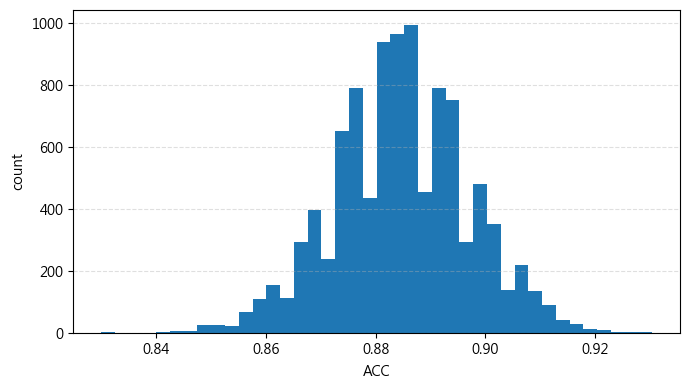

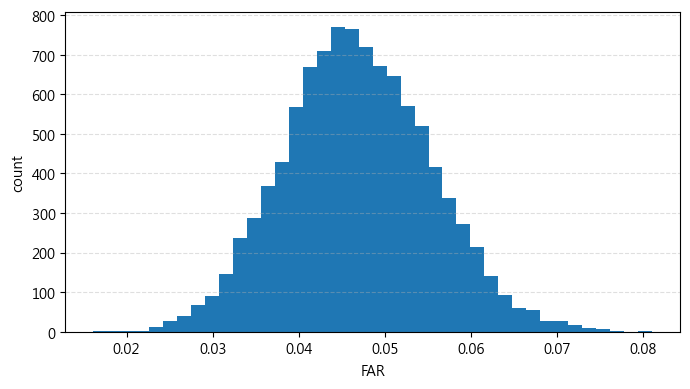

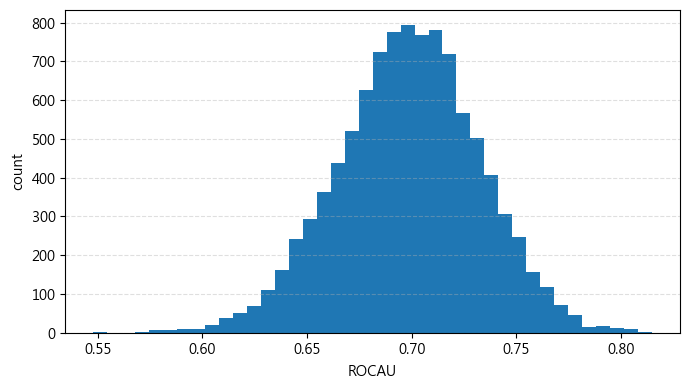


Summary (5-Fold mean):
             acc     FAR   ROCAU
model                          
XGBoost  0.8847  0.0468  0.6974


In [56]:
mask = (c_all == 0)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values.astype(int)

model = {
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        gamma=1.0,
        reg_lambda=2.0,
        reg_alpha=0.5,
        random_state=42,
        n_jobs=-1,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
    )
}

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)

    # ====== 新增：OOF 儲存（每筆樣本只會被填一次）======
    oof_score = np.full(len(y_sub), np.nan, dtype=float)  # OOF proba for positive class
    oof_true  = np.full(len(y_sub), np.nan, dtype=float)  # store y_true for safety
    # ================================================

    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)

        yhat = predict_labels(m, Xte)
        ys = predict_score(m, Xte)

        # ====== 新增：寫入 OOF ======
        oof_score[test_idx] = ys
        oof_true[test_idx] = yte
        # ==========================

        met = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)

    # ====== 新增：OOF bootstrap 95% CI ======
    # 注意：OOF 應該全部被填滿；若有 nan 代表流程有 bug
    valid = ~np.isnan(oof_score)
    ci = bootstrap_ci_from_oof(oof_true[valid], oof_score[valid], thr=0.5, B=10000, alpha=0.05, seed=42)
    print("\nOOF Bootstrap 95% CI (percentile):")
    print(f"ACC  = {ci['ACC'][0]:.4f} [{ci['ACC'][1]:.4f}, {ci['ACC'][2]:.4f}]")
    print(f"FAR  = {ci['FAR'][0]:.4f} [{ci['FAR'][1]:.4f}, {ci['FAR'][2]:.4f}]")
    print(f"ROCAU= {ci['ROCAU'][0]:.4f} [{ci['ROCAU'][1]:.4f}, {ci['ROCAU'][2]:.4f}]")

    # （可選）畫 bootstrap 分佈：三個指標各一張
    boots = ci["boots"]
    for j, lab in enumerate(["ACC", "FAR", "ROCAU"]):
        plt.figure(figsize=(7,4))
        plt.hist(boots[:, j][~np.isnan(boots[:, j])], bins=40)
        plt.xlabel(lab); plt.ylabel("count")
        plt.grid(True, axis="y", linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()
    # =====================================

metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== XGBoost ===
Fold 1: acc=0.953, FAR=0.012, ROCAU=0.589
Fold 2: acc=0.953, FAR=0.000, ROCAU=0.553
Fold 3: acc=0.959, FAR=0.000, ROCAU=0.651
Fold 4: acc=0.941, FAR=0.012, ROCAU=0.654
Fold 5: acc=0.935, FAR=0.025, ROCAU=0.686

Confusion matrix (mean over 5 folds):
[[160.6   1.6]
 [  7.2   0.4]]

OOF Bootstrap 95% CI (percentile):
ACC  = 0.9482 [0.9329, 0.9623]
FAR  = 0.0099 [0.0037, 0.0172]
ROCAU= 0.6224 [0.5228, 0.7171]


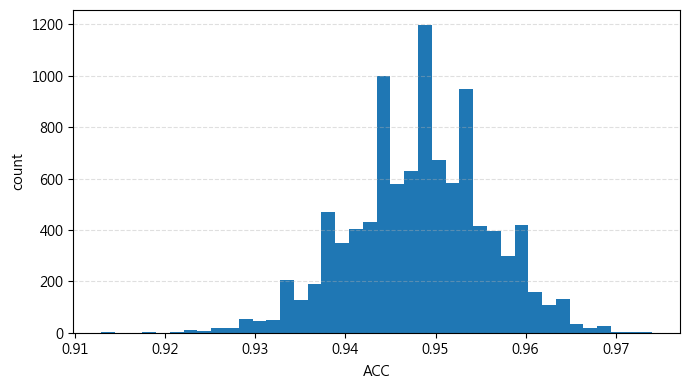

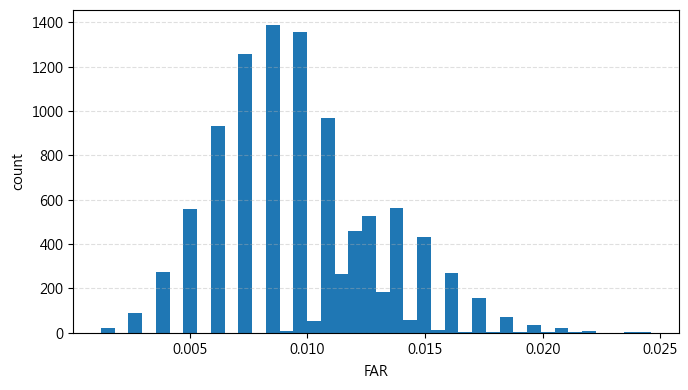

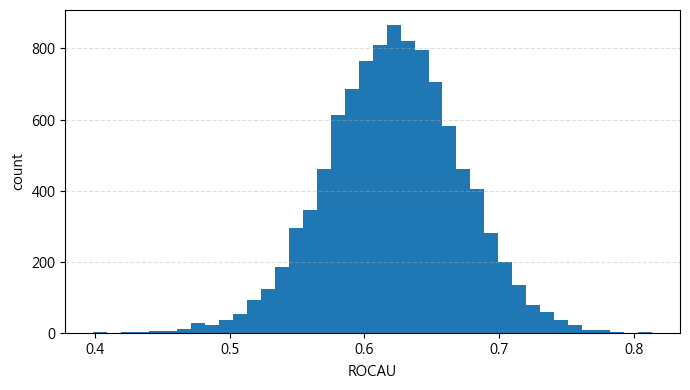


Summary (5-Fold mean):
             acc     FAR   ROCAU
model                          
XGBoost  0.9482  0.0099  0.6266


In [5]:
mask = (c_all == 1)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values.astype(int)

model = {
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        gamma=1.0,
        reg_lambda=2.0,
        reg_alpha=0.5,
        random_state=42,
        n_jobs=-1,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
    )
}

# ====== 新增：bootstrap CI（用 OOF 預測做抽樣）======
def bootstrap_ci_from_oof(y_true, y_score, thr=0.5, B=10000, alpha=0.05, seed=42):
    """
    y_true: (n,) 0/1
    y_score: (n,) OOF predicted proba for positive class (Fail)
    回傳：point estimate + percentile 95% CI for ACC, FAR, ROCAU
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    n = len(y_true)
    rng = np.random.default_rng(seed)

    def met_on_arrays(yt, ys):
        yp = (ys >= thr).astype(int)
        m = compute_metrics(yt, yp, ys)
        return m['acc'], m['FAR'], m['ROCAU']

    # point
    p_acc, p_far, p_auc = met_on_arrays(y_true, y_score)

    # bootstrap
    boots = np.empty((B, 3), dtype=float)
    for b in range(B):
        idx = rng.integers(0, n, size=n)  # sample with replacement
        boots[b, :] = met_on_arrays(y_true[idx], y_score[idx])

    lo = np.nanquantile(boots, alpha / 2, axis=0)
    hi = np.nanquantile(boots, 1 - alpha / 2, axis=0)

    return {
        "ACC": (p_acc, lo[0], hi[0]),
        "FAR": (p_far, lo[1], hi[1]),
        "ROCAU": (p_auc, lo[2], hi[2]),
        "boots": boots
    }

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)

    # ====== 新增：OOF 儲存（每筆樣本只會被填一次）======
    oof_score = np.full(len(y_sub), np.nan, dtype=float)  # OOF proba for positive class
    oof_true  = np.full(len(y_sub), np.nan, dtype=float)  # store y_true for safety
    # ================================================

    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)

        yhat = predict_labels(m, Xte)
        ys = predict_score(m, Xte)

        # ====== 新增：寫入 OOF ======
        oof_score[test_idx] = ys
        oof_true[test_idx] = yte
        # ==========================

        met = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)

    # ====== 新增：OOF bootstrap 95% CI ======
    # 注意：OOF 應該全部被填滿；若有 nan 代表流程有 bug
    valid = ~np.isnan(oof_score)
    ci = bootstrap_ci_from_oof(oof_true[valid], oof_score[valid], thr=0.5, B=10000, alpha=0.05, seed=42)
    print("\nOOF Bootstrap 95% CI (percentile):")
    print(f"ACC  = {ci['ACC'][0]:.4f} [{ci['ACC'][1]:.4f}, {ci['ACC'][2]:.4f}]")
    print(f"FAR  = {ci['FAR'][0]:.4f} [{ci['FAR'][1]:.4f}, {ci['FAR'][2]:.4f}]")
    print(f"ROCAU= {ci['ROCAU'][0]:.4f} [{ci['ROCAU'][1]:.4f}, {ci['ROCAU'][2]:.4f}]")

    # （可選）畫 bootstrap 分佈：三個指標各一張
    boots = ci["boots"]
    for j, lab in enumerate(["ACC", "FAR", "ROCAU"]):
        plt.figure(figsize=(7,4))
        plt.hist(boots[:, j][~np.isnan(boots[:, j])], bins=40)
        plt.xlabel(lab); plt.ylabel("count")
        plt.grid(True, axis="y", linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()
    # =====================================

metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))

In [4]:
def collect_test_points_near_half_per_cluster(
    X_all_df, y_all, c_all,
    n_splits=5, random_state=42,
    topn_per_cluster=30
):
    """
    回傳每個樣本在其所屬 cluster 中，作為 testing fold 時得到的 out-of-fold p_test。
    不篩 tol、不取 topk；保留所有 testing samples。
    
    最後依各群 |p_test - 0.5| 由近到遠排序，各取前 topn_per_cluster 筆。
    
    欄位包含：
    cluster, global_idx, p_test, y_true, dist, (所有 x 特徵)
    """
    
    y_all = np.asarray(y_all).astype(int)
    rows = []

    for c in np.sort(np.unique(c_all)):
        idx = np.where(c_all == c)[0]   # global indices in this cluster
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]
            te_global = idx[te]   # map back to global indices

            sm = SMOTE(
                sampling_strategy=1,
                k_neighbors=5,
                random_state=random_state
            )
            X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr_sm, y_tr_sm)

            p_te = m.predict_proba(X_te)[:, 1]
            dist = np.abs(p_te - 0.5)

            X_pick = X_all_df.iloc[te_global].copy()
            X_pick["cluster"] = int(c)
            X_pick["global_idx"] = te_global
            X_pick["p_test"] = p_te
            X_pick["y_true"] = y_all[te_global]
            X_pick["dist"] = dist
            rows.append(X_pick)

    df_all = pd.concat(rows, ignore_index=True)

    meta_cols = ["cluster", "global_idx", "p_test", "y_true", "dist"]
    feat_cols = [col for col in df_all.columns if col not in meta_cols]
    df_all = df_all[meta_cols + feat_cols]

    # 各群內依距離 0.5 由近到遠排序，取前 topn_per_cluster
    df_near30 = (
        df_all
        .sort_values(["cluster", "dist", "global_idx"], ascending=[True, True, True])
        .groupby("cluster", group_keys=False)
        .head(topn_per_cluster)
        .reset_index(drop=True)
    )

    return df_near30

df_half = collect_test_points_near_half_per_cluster(
    X_all_df=X_all_df,
    y_all=y_real,
    c_all=c_all,
    n_splits=5,
    random_state=42,
    topn_per_cluster=30
)

In [65]:
df_half[['global_idx', 'x1', 'x2', 'x589', 'x590', 'p_test', 'dist','y_true']]

,global_idx,x1,x2,x589,x590,p_test,dist,y_true
0,82,-0.921323,-0.263777,1.057470,0.172921,0.498364,0.001636,0
1,225,0.794818,-1.815294,-0.332622,-0.154877,0.516134,0.016134,0
2,44,0.367305,2.479558,0.779451,0.095199,0.481022,0.018978,0
3,144,-1.446410,-0.375622,-0.610641,-0.546260,0.527558,0.027558,0
4,345,-0.439136,-2.580404,-0.402127,0.549533,0.470658,0.029342,0
5,298,-1.341257,0.386872,-0.645393,-0.555740,0.468458,0.031542,0
6,484,0.626330,-1.382982,0.258167,-0.381150,0.533517,0.033517,1
7,105,-0.520471,0.096297,-0.263118,-0.120364,0.458454,0.041546,0
8,111,0.074718,-0.216323,0.258167,2.041247,0.457258,0.042742,0
9,247,-0.057230,0.221968,0.153910,0.059162,0.544061,0.044061,0


In [6]:
df_half[df_half['dist']<0.05].sort_values(by='dist')

,cluster,global_idx,p_test,y_true,dist,x1,x2,x3,x4,x5,...,x581,x582,x583,x584,x585,x586,x587,x588,x589,x590
0,0,82,0.498364,0,0.001636,-0.921323,-0.263777,0.689715,-0.757926,-0.058760,...,1.396335,0.393940,-0.497855,0.154430,0.014487,0.149015,-0.170825,0.671448,1.057470,0.172921
30,1,1158,0.493004,0,0.006996,-0.978433,0.898024,1.073055,1.223832,-0.053470,...,-0.347717,-0.289503,1.621640,0.027796,0.200535,0.013688,0.062890,-0.666857,-0.645393,-0.554204
31,1,990,0.513882,0,0.013882,0.747317,0.821800,1.598444,-0.814575,-0.052001,...,-0.192590,-0.471304,0.650205,-0.116107,-0.118405,-0.115173,0.417491,0.115711,-0.089356,-0.360851
1,0,225,0.516134,0,0.016134,0.794818,-1.815294,1.487459,0.622868,-0.059727,...,0.626662,0.271142,0.503018,-0.277277,-0.171561,-0.270646,-0.646313,-0.564783,-0.332622,-0.154877
2,0,44,0.481022,0,0.018978,0.367305,2.479558,0.205618,-0.353291,-0.053588,...,1.011141,0.267953,1.121204,-0.213960,-0.224718,-0.210375,-0.114411,0.592057,0.779451,0.095199
32,1,1361,0.521811,1,0.021811,0.514817,0.252607,-0.943273,-0.973435,-0.053508,...,0.240753,-0.687153,2.357576,0.027796,-0.038670,0.011836,0.699560,-0.054413,0.223414,-0.494009
33,1,1189,0.473835,1,0.026165,0.575310,-0.470903,-0.920166,-0.575247,-0.059366,...,1.061386,-0.249250,-2.205226,-0.104595,0.041065,-0.092955,-0.912264,-0.349293,0.014901,0.332787
3,0,144,0.527558,0,0.027558,-1.446410,-0.375622,0.731760,0.340708,-0.049010,...,-0.914828,-0.771852,1.297828,-0.334838,-0.357609,-0.326247,0.199895,-0.553441,-0.610641,-0.546260
34,1,1187,0.528723,0,0.028723,0.760444,-0.100990,-0.028101,-0.587430,-0.052396,...,0.424525,-0.109582,-0.262356,-0.306058,-0.331031,-0.295821,-0.066056,-0.587466,-0.714898,-0.478764
4,0,345,0.470658,0,0.029342,-0.439136,-2.580404,-0.059922,0.301241,-0.059416,...,-0.067853,0.045082,0.738517,0.079600,0.200535,0.070836,-1.129861,-0.587466,-0.402127,0.549533


In [19]:
def pick_test_points_near_one_per_cluster(
    X_all_df, y_all, c_all,
    n_splits=5, random_state=42,
    tol=0.01,          # |p-0.5| <= tol
    topk=None,         # 若不想用 tol，改用每個 fold 取 topk 個最接近 1
):
    """
    回傳 df_sel：
    每筆為一個「testing fold」上的樣本點，
    欄位包含：cluster, fold_id, global_idx, p_test, y_true, (所有 x 特徵)
    """
    y_all = np.asarray(y_all).astype(int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rows = []

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]              # global indices in this cluster
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        fold_id = 0
        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]
            te_global = idx[te]                    # map back to global indices

            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr_sm, y_tr_sm)

            p_te = m.predict_proba(X_te)[:, 1]
            dist = np.abs(p_te - 1)

            if topk is not None:
                pick = np.argsort(dist)[:min(int(topk), len(te))]
            else:
                pick = np.where(dist <= tol)[0]

            if pick.size > 0:
                picked_global = te_global[pick]
                X_pick = X_all_df.iloc[picked_global].copy()
                X_pick["y_true"] = y_all[picked_global]
                X_pick["p_test"] = p_te[pick]
                X_pick["global_idx"] = picked_global
                X_pick["cluster"] = int(c)
                X_pick["fold_id"] = int(fold_id)
                rows.append(X_pick)

            fold_id += 1

    df_sel = pd.concat(rows, ignore_index=True) if len(rows) else pd.DataFrame()
    if len(df_sel):
        # 讓欄位順序清楚：meta 在前，特徵在後
        meta_cols = ["cluster", "fold_id", "global_idx", "p_test", "y_true"]
        feat_cols = [c for c in df_sel.columns if c not in meta_cols]
        df_sel = df_sel[meta_cols + feat_cols].sort_values(
            ["cluster", "fold_id", "p_test"], ascending=[True, True, True]
        ).reset_index(drop=True)
    return df_sel

df_one = pick_test_points_near_one_per_cluster(
    X_all_df=X_all_df,
    y_all=y_real,
    c_all=c_all,
    n_splits=5,
    random_state=42,
    tol=0.01,
    topk=10
)

df_one

,cluster,fold_id,global_idx,p_test,y_true,x1,x2,x3,x4,x5,...,x581,x582,x583,x584,x585,x586,x587,x588,x589,x590
0,0,0,292,0.570125,0,-3.078105,1.107517,0.801839,0.246799,-0.048457,...,-0.203213,-0.356339,0.591330,-0.352107,-0.304452,-0.339926,-0.871969,-1.052470,-0.958164,-0.348680
1,0,0,211,0.576047,0,-0.754324,-0.045192,-0.658799,-0.880132,-0.051795,...,-0.126554,-0.137693,0.473580,-0.150643,-0.171561,-0.148473,-0.493190,1.215843,1.787268,0.824068
2,0,0,236,0.579679,0,-0.596392,1.439193,-0.500082,-0.914652,-0.051790,...,1.974126,1.404492,0.620767,-0.323326,-0.357609,-0.313397,-0.404540,1.385966,1.474497,0.796333
3,0,0,161,0.606773,0,0.132640,0.727017,-0.977365,-0.887918,-0.050237,...,0.192604,1.352984,-1.057166,-0.058546,-0.012091,-0.050867,-0.831673,0.308518,0.188662,0.764557
4,0,0,96,0.635472,0,-0.965712,0.214993,-0.974334,0.927846,-0.051620,...,-0.481485,-0.615146,0.709080,-0.340594,-0.304452,-0.328569,0.312722,-0.213194,-0.297870,-0.449587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,4,1233,0.353403,0,0.130069,-0.887398,1.876482,0.817710,-0.054405,...,1.228863,0.150789,0.267518,0.281064,0.173956,0.266269,-0.251416,-0.179170,0.049653,-0.200382
96,1,4,990,0.513882,0,0.747317,0.821800,1.598444,-0.814575,-0.052001,...,-0.192590,-0.471304,0.650205,-0.116107,-0.118405,-0.115173,0.417491,0.115711,-0.089356,-0.360851
97,1,4,1054,0.540420,0,2.317165,-2.232162,-1.041004,-0.689082,-0.052298,...,-0.722231,-0.600493,0.650205,0.678234,0.439739,0.644589,0.103185,-0.360635,-0.471632,-0.440548
98,1,4,1116,0.581546,0,2.119310,-0.739557,-1.083427,-1.139880,-0.060979,...,-0.761027,-0.610559,1.180079,-0.357863,-0.304452,-0.347471,1.118635,0.195102,0.223414,-0.511450


---
---

# PCA

累積解釋變異比例: 
[0.0364935  0.06494198 0.09087838 0.11352847 0.13478539 0.15391366
 0.17104057 0.18778762 0.20317487 0.21766693 0.231793   0.24547244
 0.25897245 0.27230731 0.28509384 0.29754302 0.30953182 0.32136606
 0.33276204 0.34379588 0.35454847 0.36526404 0.37567605 0.3859309
 0.39600563 0.4057091  0.41526716 0.42471444 0.43383831 0.44280477
 0.45159892 0.46013775 0.4685875  0.47691485 0.4849973  0.49306181
 0.50089299 0.50859726 0.51617593 0.52362146 0.53097314 0.53830276
 0.54556402 0.55269151 0.55972787 0.56658465 0.57338393 0.58016444
 0.58686554 0.59340321 0.59984628 0.60614619 0.61237815 0.61844645
 0.62434889 0.63022256 0.63604048 0.64176732 0.64735518 0.6529231
 0.65842525 0.66384637 0.66920533 0.67454479 0.67976698 0.68490043
 0.68997999 0.69495846 0.69985725 0.70474245 0.70952694 0.71424065
 0.71879876 0.72329272 0.72774329 0.73212279 0.736382   0.74058609
 0.74472957 0.74885823 0.75293398 0.75693898 0.76086234 0.76474606
 0.76856005 0.77235182 0.77601906 0.77962517 0.783132

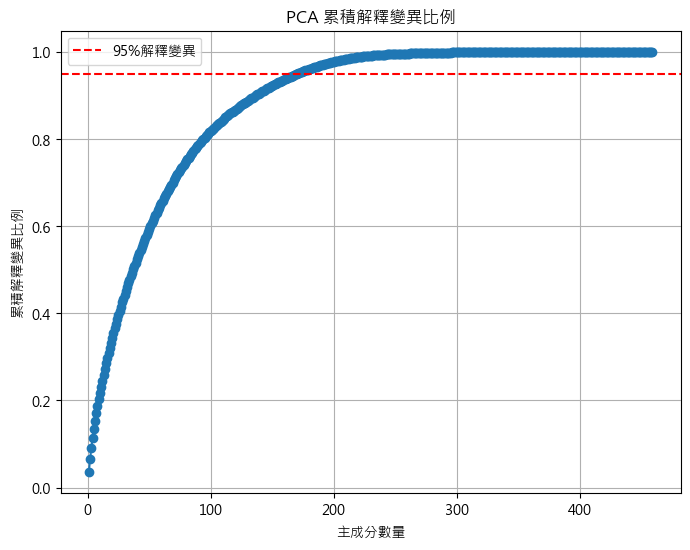

保留至少95%變異需要的主成分數量:171


In [169]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA()
X_pca = pca.fit_transform(X_std)

explained_variance_ratio = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance_ratio)
print('累積解釋變異比例: ')
print(cumulative_variance)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o', linestyle = '--')
plt.xlabel('主成分數量')
plt.ylabel('累積解釋變異比例')
plt.title('PCA 累積解釋變異比例')
plt.axhline(y = 0.95, color = 'r', linestyle = '--', label = '95%解釋變異')
plt.legend()
plt.grid()
plt.show()

n_component_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'保留至少95%變異需要的主成分數量:{n_component_95}')


使用 96 個特徵做 PCA
累積解釋變異比例： [0.04449906 0.08752489 0.13001329 0.16467381 0.19785249 0.23068966
 0.25743204 0.28328585 0.30791427 0.33148236 0.35342189 0.3749464
 0.39511501 0.41433725 0.43332914 0.45180105 0.4693046  0.48605213
 0.5025279  0.51789975 0.53282602 0.54732579 0.56133248 0.57427714
 0.58702736 0.59966179 0.61204751 0.62419367 0.63607978 0.647731
 0.65917282 0.67030108 0.68131537 0.69209953 0.70279707 0.71321526
 0.72357737 0.7338412  0.74387707 0.75360846 0.76327406 0.77280512
 0.78214053 0.79129894 0.80032404 0.80931488 0.81794966 0.82655268
 0.83481222 0.84298976 0.85108466 0.85904655 0.86695753 0.87460224
 0.88210068 0.88941352 0.89659238 0.90362663 0.91052975 0.91713743
 0.92352836 0.92972091 0.93581867 0.94173679 0.94746191 0.95302236
 0.95834664 0.96347368 0.96818555 0.97273764 0.97718454 0.9813862
 0.98514902 0.98834756 0.99062308 0.99251279 0.99426501 0.99586637
 0.99695657 0.99761581 0.99826945 0.99871289 0.9990224  0.99930351
 0.9995273  0.99972971 0.99982503 0.99991

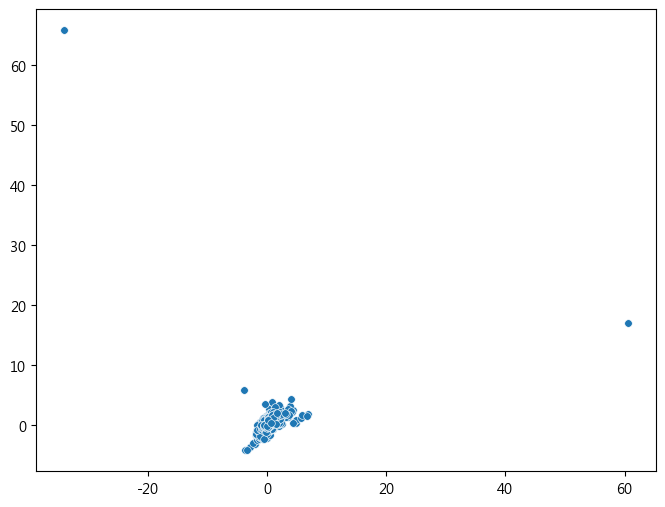

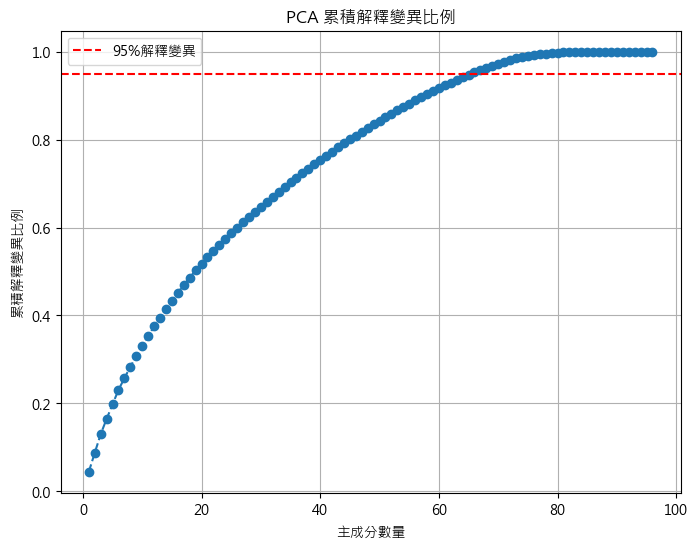

保留至少95%變異需要的主成分數量:66


In [34]:
c0_final = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\0 Meeting\p=half_c0_final_B=50_topk=12_k=2_delta=01_n=100w.csv', sep='\t')

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
# 只取局部線性模型最後保留的特徵
feat_use = [f for f in c0_final['feature'].tolist() if f in secom.columns]
print(f'使用 {len(feat_use)} 個特徵做 PCA')

X = secom[feat_use].copy()

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA()
X_pca = pca.fit_transform(X_std)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
# print('各主成分解釋變異比例：', pca.explained_variance_ratio_)
print('累積解釋變異比例：', pca.explained_variance_ratio_.cumsum())

X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], s=30)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o', linestyle = '--')
plt.xlabel('主成分數量')
plt.ylabel('累積解釋變異比例')
plt.title('PCA 累積解釋變異比例')
plt.axhline(y = 0.95, color = 'r', linestyle = '--', label = '95%解釋變異')
plt.legend()
plt.grid()
plt.show()


n_component_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'保留至少95%變異需要的主成分數量:{n_component_95}')